In [1]:
%load_ext autoreload
%autoreload 2
%run -i loader/dataloader_hurricane.py

In [2]:
from loader.dataloader_hurricane import *

# data_df=pd.read_csv("/Users/noujoudnader/Library/CloudStorage/OneDrive-LouisianaStateUniversity/CCT RESEARCH/Hurricanes/stgat_traffic_prediction-main/Correlations/Ian_hydro.csv",low_memory=False).dropna()
data_df=pd.read_csv("STOFSatl_hydro.csv", low_memory=False).dropna()
# station_info = pd.read_csv('stations_Ian.csv')

# Remove outliers
std = data_df['offset'].std()
data_df = data_df.where(data_df['offset'].abs() < 3*np.abs(std)).dropna()

data_df = data_df.where(data_df['offset'].abs() < 3*np.abs(std)).dropna()


print("Storms:")
print(data_df['storm'].unique())

Storms:
['CHARLEY' 'HERMINE' 'MATTHEW' 'HARVEY' 'IDA' 'IAN' 'IDALIA']


In [3]:
# Find common station IDs through all storms

storms = data_df['storm'].unique()
ids_per_storm = {}
for storm in storms:
    ids_per_storm[storm] = data_df[data_df['storm']==storm]['station_id'].unique().tolist()

common_ids = list(set.intersection(*map(set, [ids_per_storm[storm] for storm in storms])))
print("No. of common stations before droping NaN values:")
print(len(common_ids))

No. of common stations before droping NaN values:
86


In [4]:
station_info_df = data_df[data_df['station_id'].isin(common_ids)][['x', 'y', 'station_name', 'station_id', 'agency']].drop_duplicates()
print(station_info_df['agency'].unique())

['USGS' 'USACE' 'NOAA_NOS' 'TCOON']


In [5]:

import matplotlib.pyplot as plt

import cartopy.crs as crs
import cartopy.feature as cfeature

def scale_bar(ax, length=None, location=(0.5, 0.05), linewidth=3):
    """
    ax is the axes to draw the scalebar on.
    length is the length of the scalebar in km.
    location is center of the scalebar in axis coordinates.
    (ie. 0.5 is the middle of the plot)
    linewidth is the thickness of the scalebar.
    """
    #Get the limits of the axis in lat long
    llx0, llx1, lly0, lly1 = ax.get_extent(crs.PlateCarree())
    #Make tmc horizontally centred on the middle of the map,
    #vertically at scale bar location
    sbllx = (llx1 + llx0) / 2
    sblly = lly0 + (lly1 - lly0) * location[1]
    tmc = crs.TransverseMercator(sbllx, sblly)
    #Get the extent of the plotted area in coordinates in metres
    x0, x1, y0, y1 = ax.get_extent(tmc)
    #Turn the specified scalebar location into coordinates in metres
    sbx = x0 + (x1 - x0) * location[0]
    sby = y0 + (y1 - y0) * location[1]

    #Calculate a scale bar length if none has been given
    #(Theres probably a more pythonic way of rounding the number but this works)
    if not length: 
        length = (x1 - x0) / 5000 #in km
        ndim = int(np.floor(np.log10(length))) #number of digits in number
        length = round(length, -ndim) #round to 1sf
        #Returns numbers starting with the list
        def scale_number(x):
            if str(x)[0] in ['1', '2', '5']: return int(x)        
            else: return scale_number(x - 10 ** ndim)
        length = scale_number(length) 

    #Generate the x coordinate for the ends of the scalebar
    bar_xs = [sbx - length * 500, sbx + length * 500]
    #Plot the scalebar
    ax.plot(bar_xs, [sby, sby], transform=tmc, color='k', linewidth=linewidth)
    #Plot the scalebar label
    ax.text(sbx, sby, str(length) + ' km', transform=tmc,
            horizontalalignment='center', verticalalignment='bottom')

c:\Users\Stefanos\AppData\Local\Programs\Python\Python311\Lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


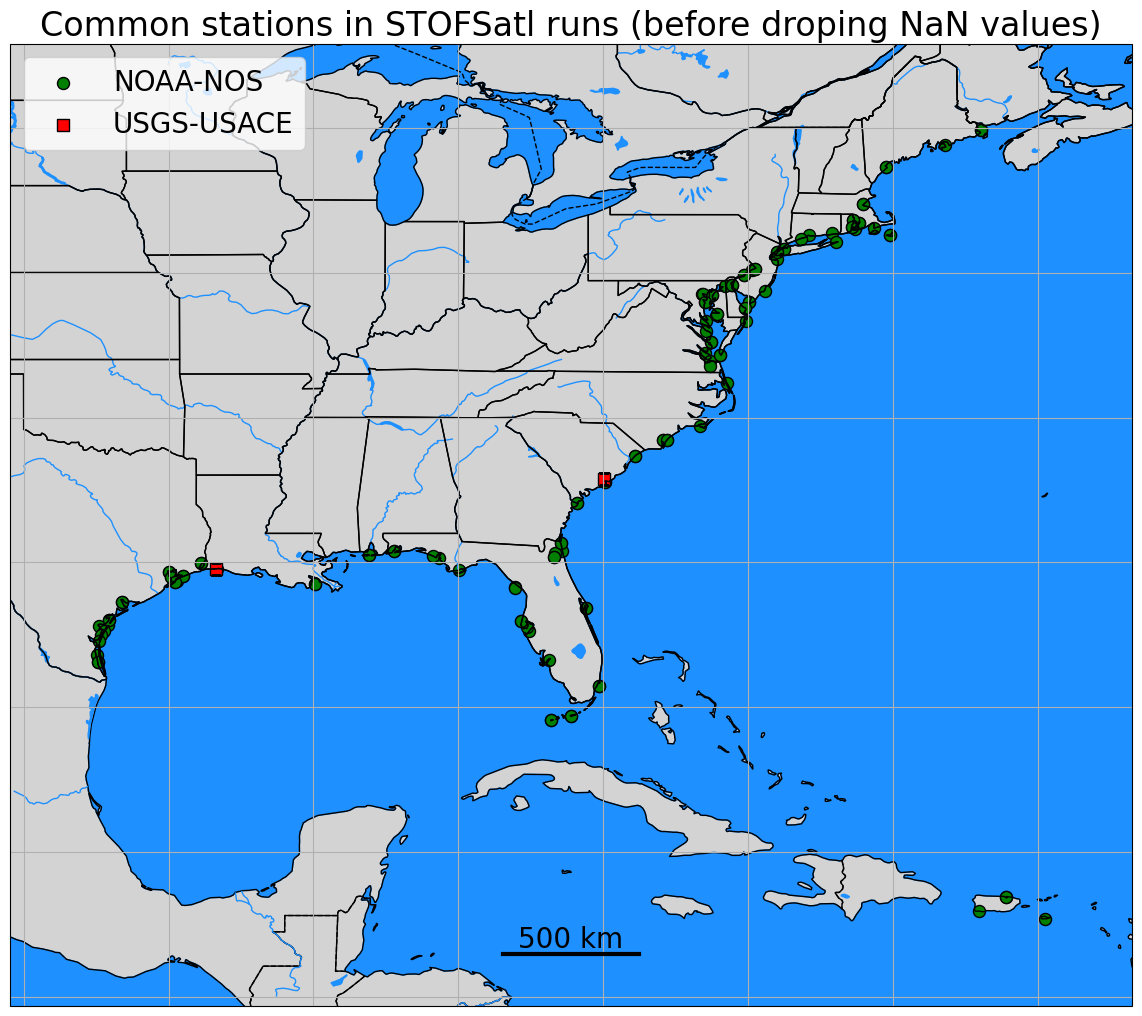

In [6]:
station_info_df_NOOA = station_info_df[(station_info_df['agency'] == 'NOAA_NOS') | (station_info_df['agency'] == 'TCOON')]
station_info_df_USGS = station_info_df[(station_info_df['agency'] == 'USGS') | (station_info_df['agency'] == 'USACE')]



plt.rcParams['figure.figsize'] = [25, 12.5]
plt.rcParams.update({'font.size': 20})

fig = plt.figure()
ax = fig.add_subplot(1,1,1, projection=crs.PlateCarree())
# fig, ax = plt.subplots()
ax.set_global()
# ax.stock_img()
ax.add_feature(cfeature.COASTLINE, edgecolor="black")
ax.add_feature(cfeature.BORDERS, edgecolor="black")
ax.add_feature(cfeature.LAND, color="lightgrey")
ax.add_feature(cfeature.LAKES, color="dodgerblue")
ax.add_feature(cfeature.BORDERS, linestyle="--")
ax.add_feature(cfeature.OCEAN, color="dodgerblue")
ax.add_feature(cfeature.RIVERS, color="dodgerblue")
ax.add_feature(cfeature.STATES)
ax.gridlines()

im1 = ax.scatter(station_info_df_NOOA['x'], station_info_df_NOOA['y'], c = 'green',
                  edgecolors='black',
                    s=75,
                      alpha=1.0,
                        label='NOAA-NOS')
im2 = ax.scatter(station_info_df_USGS['x'], station_info_df_USGS['y'], c = 'red',
                  marker = 's',
                    edgecolors='black',
                      s=75, alpha=1.0,
                        label='USGS-USACE')

plt.xlim((station_info_df['x'].min()-3, station_info_df['x'].max()+3))
plt.ylim((station_info_df['y'].min()-3, station_info_df['y'].max()+3))

plt.legend()
scale_bar(ax, 500)
plt.title('Common stations in STOFSatl runs (before droping NaN values)')
plt.show()

In [7]:
# Constant config to use throughout
config = {
    'BATCH_SIZE': 10,
    'EPOCHS': 100,
    'WEIGHT_DECAY': 5e-4,
    'INITIAL_LR': 3e-3,
    'CHECKPOINT_DIR': './runs',
    'N_PRED': 9,
    'N_HIST': 15,
    'DROPOUT': 0.2,
    # number of possible 5 minute measurements per day
    # number of days worth of data in the dataset
    # If false, use GCN paper weight matrix, if true, use GAT paper weight matrix
    'USE_GAT_WEIGHTS': True,
    # ['CHARLEY' 'HERMINE' 'MATTHEW' 'HARVEY' 'IDA' 'IAN' 'IDALIA']
    'SPLITS': {
    'TRAIN_STORMS': ['CHARLEY', 'HERMINE', 'MATTHEW', 'HARVEY', 'IDA'],
    'VAL_STORMS': ['IDALIA'],
    'TEST_STORMS': ['IAN'],
    }
}
# Number of possible windows in a day
# config['N_SLOT']= config['N_DAY_SLOT'] - (config['N_PRED']+config['N_HIST']) + 1

In [52]:
# Split df based on config["SPLITS"]
df_train, df_val, df_test = get_splits_hurricanes(data_df, config['SPLITS'])

# Create station df_* from df_*
station_df_train =create_stationDf(df_train, common_ids, 'offset')
station_df_val =create_stationDf(df_val, common_ids, 'offset')
station_df_test =create_stationDf(df_test, common_ids, 'offset')

new_common_ids = list(set(station_df_train.columns.values) & set(station_df_val.columns.values) & set(station_df_test.columns.values))
station_df_train = station_df_train[station_df_train.columns.intersection(new_common_ids)]
station_df_val = station_df_val[station_df_val.columns.intersection(new_common_ids)]
station_df_test = station_df_test[station_df_test.columns.intersection(new_common_ids)]

print(len(station_df_train.columns.values))



74


In [9]:
# Ids=data_df['station_id'].unique()   
station_df=create_stationDf(data_df,common_ids, 'offset')
config['N_NODE'] = station_df.shape[1]
# print(station_df.shape)
# print(station_df.tail(20))
print("Number of common stations after droping NaN values\n", len(station_df.columns.values))

Number of common stations after droping NaN values
 74


In [10]:
station_info_df = data_df[data_df['station_id'].isin(station_df.columns.values)][['x', 'y', 'station_name', 'station_id', 'agency']].drop_duplicates()
print(station_info_df['agency'].unique())

['NOAA_NOS' 'TCOON']


c:\Users\Stefanos\AppData\Local\Programs\Python\Python311\Lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


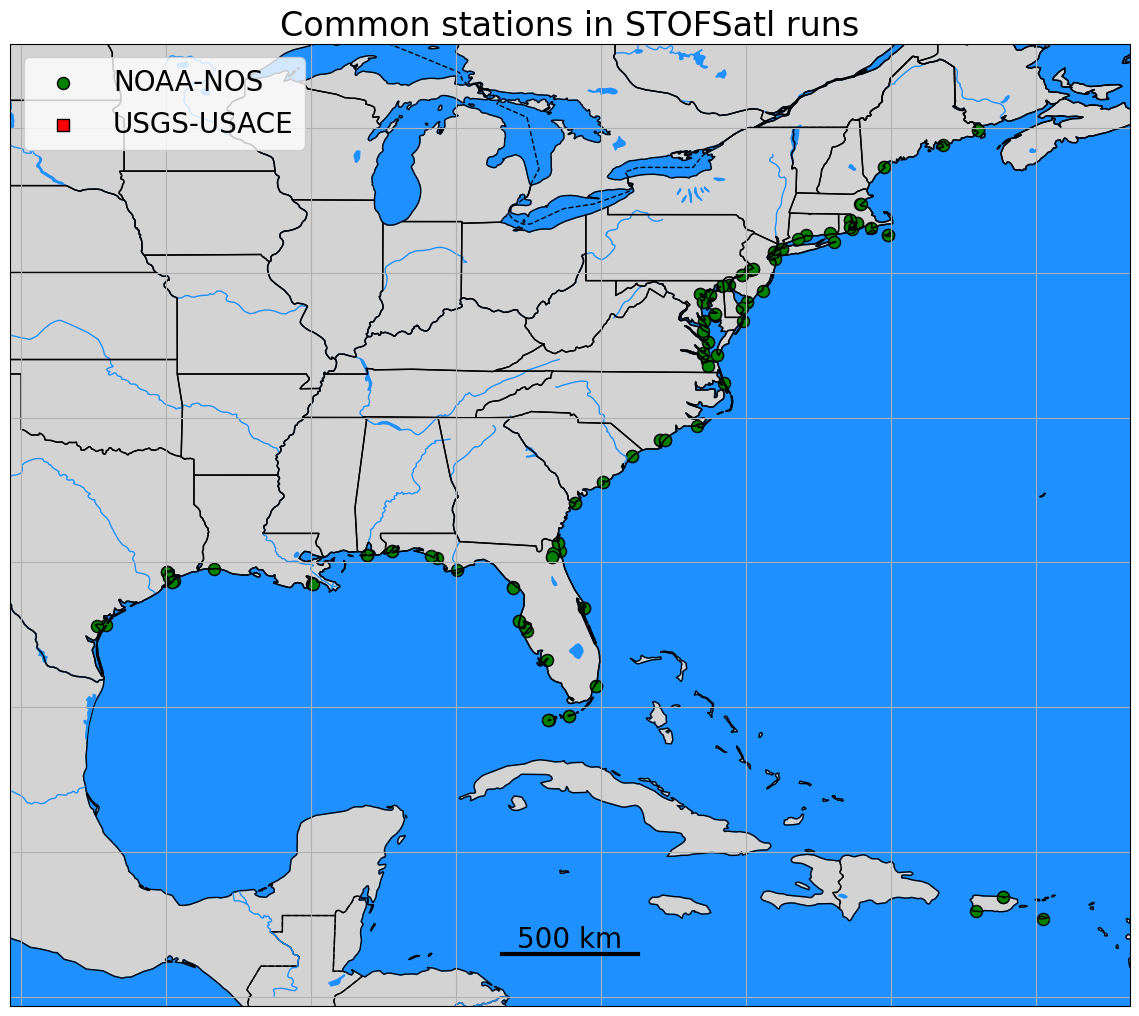

In [11]:
station_info_df_NOOA = station_info_df[(station_info_df['agency'] == 'NOAA_NOS') | (station_info_df['agency'] == 'TCOON')]
station_info_df_USGS = station_info_df[(station_info_df['agency'] == 'USGS') | (station_info_df['agency'] == 'USACE')]



plt.rcParams['figure.figsize'] = [25, 12.5]
plt.rcParams.update({'font.size': 20})

fig = plt.figure()
ax = fig.add_subplot(1,1,1, projection=crs.PlateCarree())
# fig, ax = plt.subplots()
ax.set_global()
# ax.stock_img()
ax.add_feature(cfeature.COASTLINE, edgecolor="black")
ax.add_feature(cfeature.BORDERS, edgecolor="black")
ax.add_feature(cfeature.LAND, color="lightgrey")
ax.add_feature(cfeature.LAKES, color="dodgerblue")
ax.add_feature(cfeature.BORDERS, linestyle="--")
ax.add_feature(cfeature.OCEAN, color="dodgerblue")
ax.add_feature(cfeature.RIVERS, color="dodgerblue")
ax.add_feature(cfeature.STATES)
ax.gridlines()

im1 = ax.scatter(station_info_df_NOOA['x'], station_info_df_NOOA['y'], c = 'green',
                  edgecolors='black',
                    s=75,
                      alpha=1.0,
                        label='NOAA-NOS')
im2 = ax.scatter(station_info_df_USGS['x'], station_info_df_USGS['y'], c = 'red',
                  marker = 's',
                    edgecolors='black',
                      s=75, alpha=1.0,
                        label='USGS-USACE')

plt.xlim((station_info_df['x'].min()-3, station_info_df['x'].max()+3))
plt.ylim((station_info_df['y'].min()-3, station_info_df['y'].max()+3))

plt.legend()
scale_bar(ax, 500)
plt.title('Common stations in STOFSatl runs')
plt.show()

In [12]:
# # Test windowing
# sliding_step = 1

# n_window = config['N_PRED'] + config['N_HIST'] # full window length

# # config['N_Windows']=int(len(station_df)/n_window)  # Works only for non-overlapping windows
# config['N_Windows'] = int((len(station_df) - n_window)/sliding_step)+1

# x = np.ones((station_df.shape[1], config['N_HIST']*config['N_Windows']))*np.nan
# y = np.ones((station_df.shape[1], config['N_PRED']*config['N_Windows']))*np.nan


# # full_window = np.ones((station_df.shape[1], n_window*config['N_Windows']))*np.nan

# # print(n_window)
# # print(sliding_step)
# # print(config['N_Windows'])

# # print(full_window.shape[1])


# for count, i in enumerate(range(0, len(station_df), sliding_step)):

#     sta=i
#     end = sta + n_window
    
#     if end > len(station_df):
#         break

#     data=np.array(station_df.iloc[sta:end,:].values)
#     data=np.swapaxes(data, 0, 1) #data is the offset of all stations

#     x[:,count*config['N_HIST']:count*config['N_HIST']+config['N_HIST']] = data[:, :config['N_HIST']]
#     y[:,count*config['N_PRED']:count*config['N_PRED']+config['N_PRED']] = data[:, config['N_HIST']::]

In [13]:
# Test: Create station_df
# Ids=data_df['station_id'].unique()   
# station_df=create_stationDf(data_df,Ids, 'offset')

# print(station_df.columns)
# station_ids = station_df.columns
# data_train = data_df[data_df['storm'].isin(config['SPLITS']['TRAIN_STORMS'])]
# data_val = data_df[data_df['storm'].isin(config['SPLITS']['TRAIN_STORMS'])]
# data_test = data_df[data_df['storm'].isin(config['SPLITS']['TRAIN_STORMS'])]

# data_train



In [14]:
train_gnn, val_gnn, test_gnn, scaler=prepare_gnn_data(data_df, config, W_mask=1000, Corr_mask=0.7)

In [15]:
test_gnn

[Data(edge_index=[2, 884], edge_attr=[884], x=[74, 15], y=[74, 9]),
 Data(edge_index=[2, 884], edge_attr=[884], x=[74, 15], y=[74, 9]),
 Data(edge_index=[2, 884], edge_attr=[884], x=[74, 15], y=[74, 9]),
 Data(edge_index=[2, 884], edge_attr=[884], x=[74, 15], y=[74, 9]),
 Data(edge_index=[2, 884], edge_attr=[884], x=[74, 15], y=[74, 9]),
 Data(edge_index=[2, 884], edge_attr=[884], x=[74, 15], y=[74, 9]),
 Data(edge_index=[2, 884], edge_attr=[884], x=[74, 15], y=[74, 9]),
 Data(edge_index=[2, 884], edge_attr=[884], x=[74, 15], y=[74, 9]),
 Data(edge_index=[2, 884], edge_attr=[884], x=[74, 15], y=[74, 9]),
 Data(edge_index=[2, 884], edge_attr=[884], x=[74, 15], y=[74, 9]),
 Data(edge_index=[2, 884], edge_attr=[884], x=[74, 15], y=[74, 9]),
 Data(edge_index=[2, 884], edge_attr=[884], x=[74, 15], y=[74, 9]),
 Data(edge_index=[2, 884], edge_attr=[884], x=[74, 15], y=[74, 9]),
 Data(edge_index=[2, 884], edge_attr=[884], x=[74, 15], y=[74, 9])]

In [16]:
from torch_geometric.loader import DataLoader

train_dataloader = DataLoader(train_gnn, batch_size=config['BATCH_SIZE'], shuffle=True)
val_dataloader = DataLoader(val_gnn, batch_size=config['BATCH_SIZE'], shuffle=True)
test_dataloader = DataLoader(test_gnn, batch_size=config['BATCH_SIZE'], shuffle=False) # find a divisor of 143

In [68]:
test_dataloader.dataset[0].y[-1,:]

tensor([0.4155, 0.4145, 0.4138, 0.4098, 0.4133, 0.4108, 0.4120, 0.4092, 0.4079])

In [17]:
from models.trainer import load_from_checkpoint, model_train, model_test
from torch_geometric.loader import DataLoader


 # Get gpu if you can
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using {device}")

# Configure and train model
config['N_NODE'] = train_gnn[0].x.shape[0]
print(config['N_NODE'])
model = model_train(train_dataloader, val_dataloader, config, device)

Using cpu
74


Epoch 0: 100%|██████████| 80/80 [00:04<00:00, 16.64it/s]


Loss: 0.00367
Train, MAE: 0.05643194913864136, RMSE: 0.07213094085454941
Valid, MAE: 0.03808701038360596, RMSE: 0.05155482515692711


Epoch 1: 100%|██████████| 80/80 [00:05<00:00, 14.88it/s]


Loss: 0.00369


...

Loss: 0.00614


Epoch 98: 100%|██████████| 80/80 [00:03<00:00, 22.15it/s]


Loss: 0.00331


Epoch 99: 100%|██████████| 80/80 [00:03<00:00, 22.52it/s]

Loss: 0.00565


Truth:  torch.Size([740, 9])
Pred:  torch.Size([740, 9])


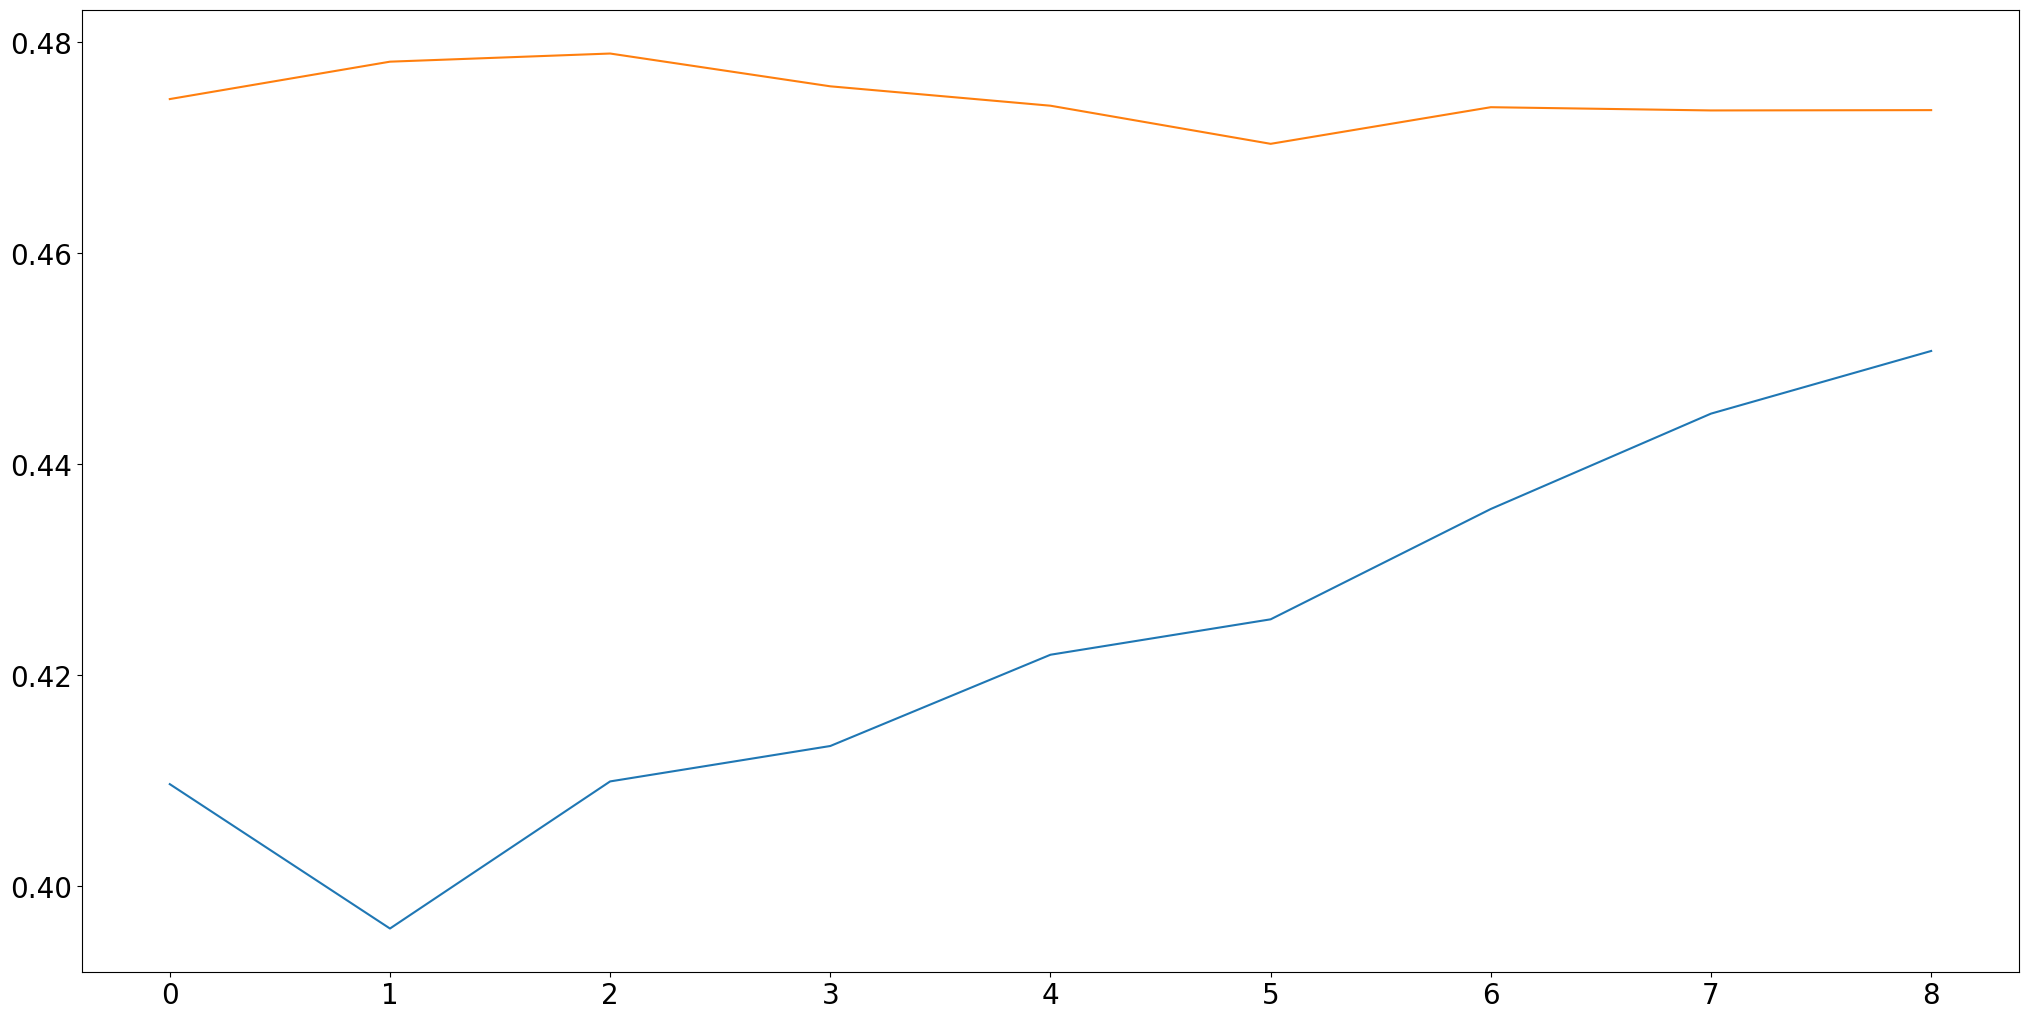

Truth:  torch.Size([296, 9])
Pred:  torch.Size([296, 9])


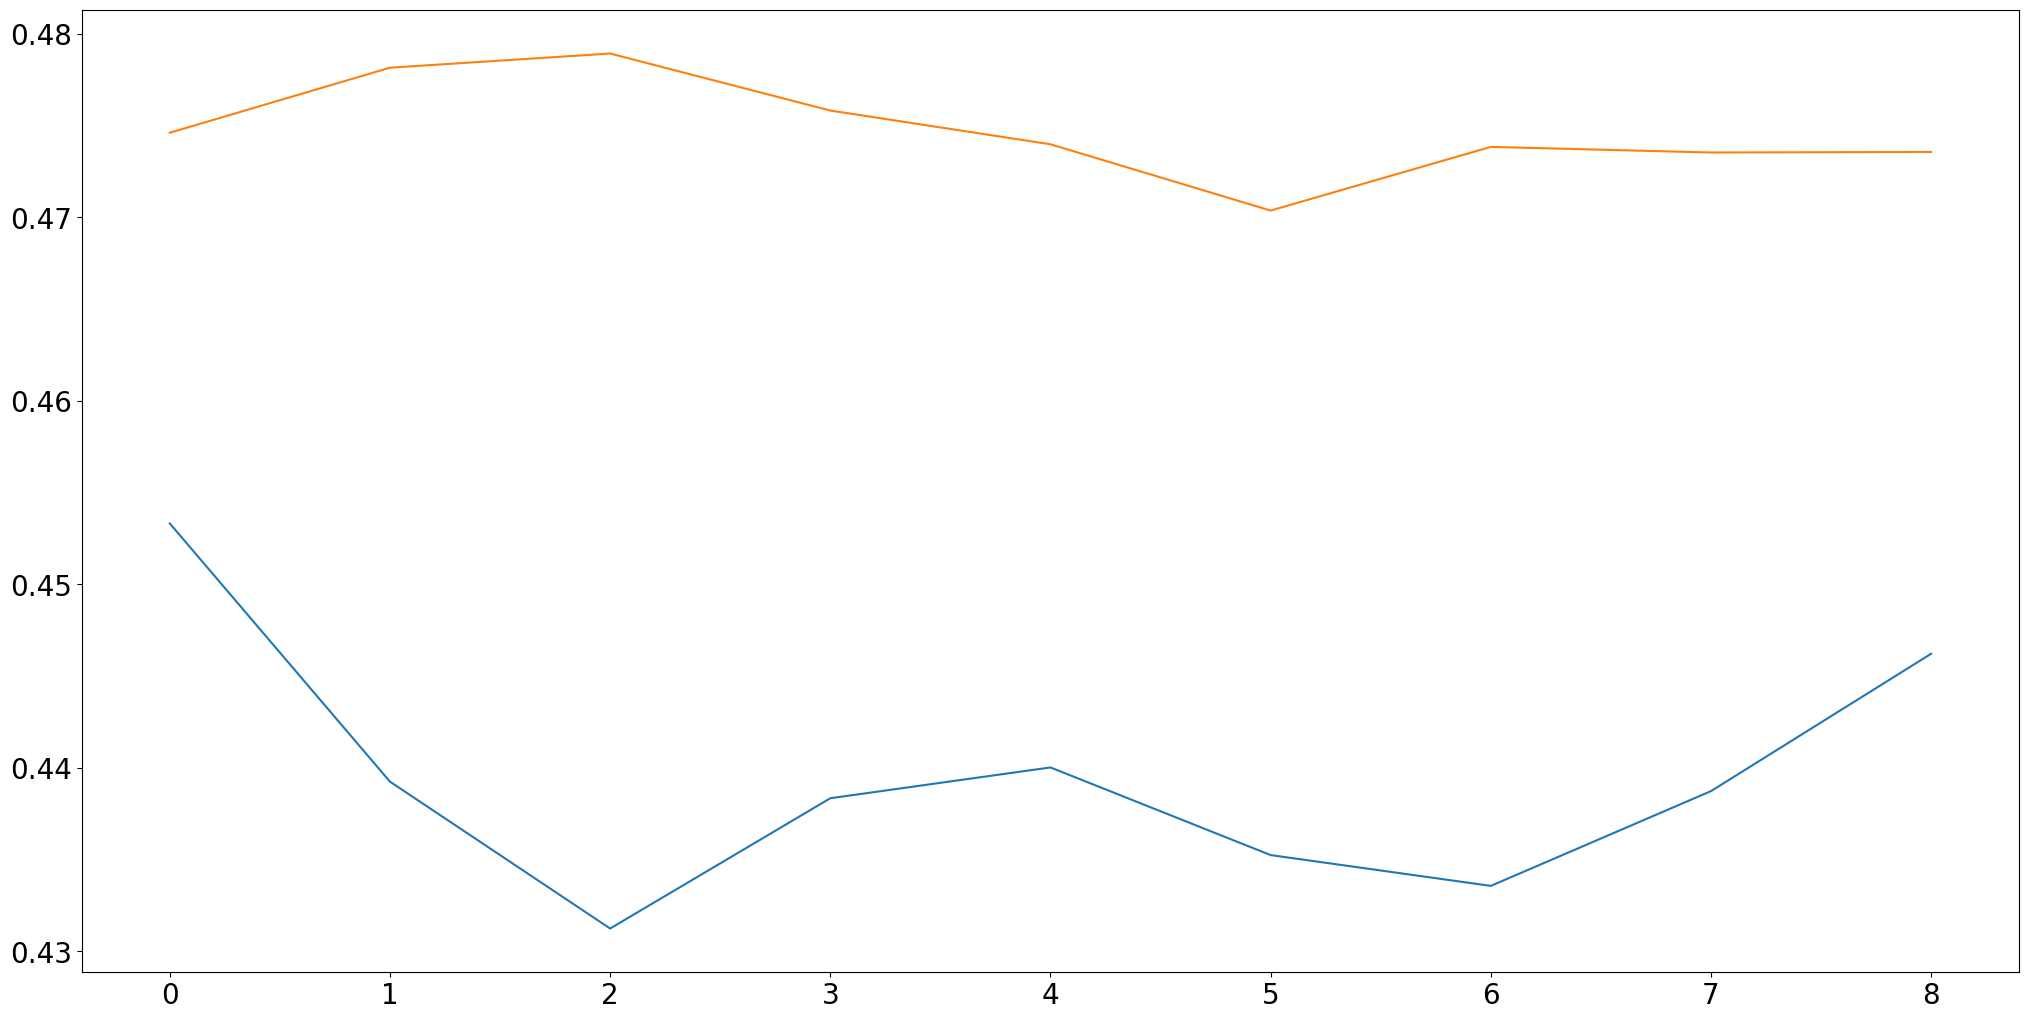

torch.Size([2, 10, 74, 9])


In [75]:
for i, batch in enumerate(test_dataloader):
    batch = batch.to(device)
    if batch.x.shape[0] == 1:
        pass
    else:
        # plt.figure()
        with torch.no_grad():
            pred = model(batch, device)
        
        truth = batch.y.view(pred.shape)
        print("Truth: ",truth.shape)
        print("Pred: ", pred.shape)
        plt.plot(truth[-1,:])
        plt.plot(pred[-1,:])
        plt.show()


        if i == 0:
            y_pred = torch.zeros(len(test_dataloader), pred.shape[0], pred.shape[1])
            y_truth = torch.zeros(len(test_dataloader), pred.shape[0], pred.shape[1])
        # truth = un_z_score(truth, dataloader.dataset.mean, dataloader.dataset.std_dev)
        # pred = un_z_score(pred, dataloader.dataset.mean, dataloader.dataset.std_dev)
        y_pred[i, :pred.shape[0], :] = pred
        y_truth[i, :pred.shape[0], :] = truth

s = y_truth.shape
num=int(s[1]* s[-1])
num2=config['N_NODE']*s[-1] 
y_truth = y_truth.reshape(s[0], int(num/num2), config['N_NODE'], s[-1])
print(y_truth.shape)

# Calculate the predicted
s = y_pred.shape
y_pred = y_pred.reshape(s[0], int(num/num2) ,config['N_NODE'], s[-1])

# Inverse scaling
y_truth = scaler.inverse_transform(y_truth.reshape(-1,1)).reshape(y_truth.shape[0], y_truth.shape[1], y_truth.shape[2], y_truth.shape[3])
y_pred = scaler.inverse_transform(y_pred.reshape(-1,1)).reshape(y_pred.shape[0], y_pred.shape[1], y_pred.shape[2], y_pred.shape[3])

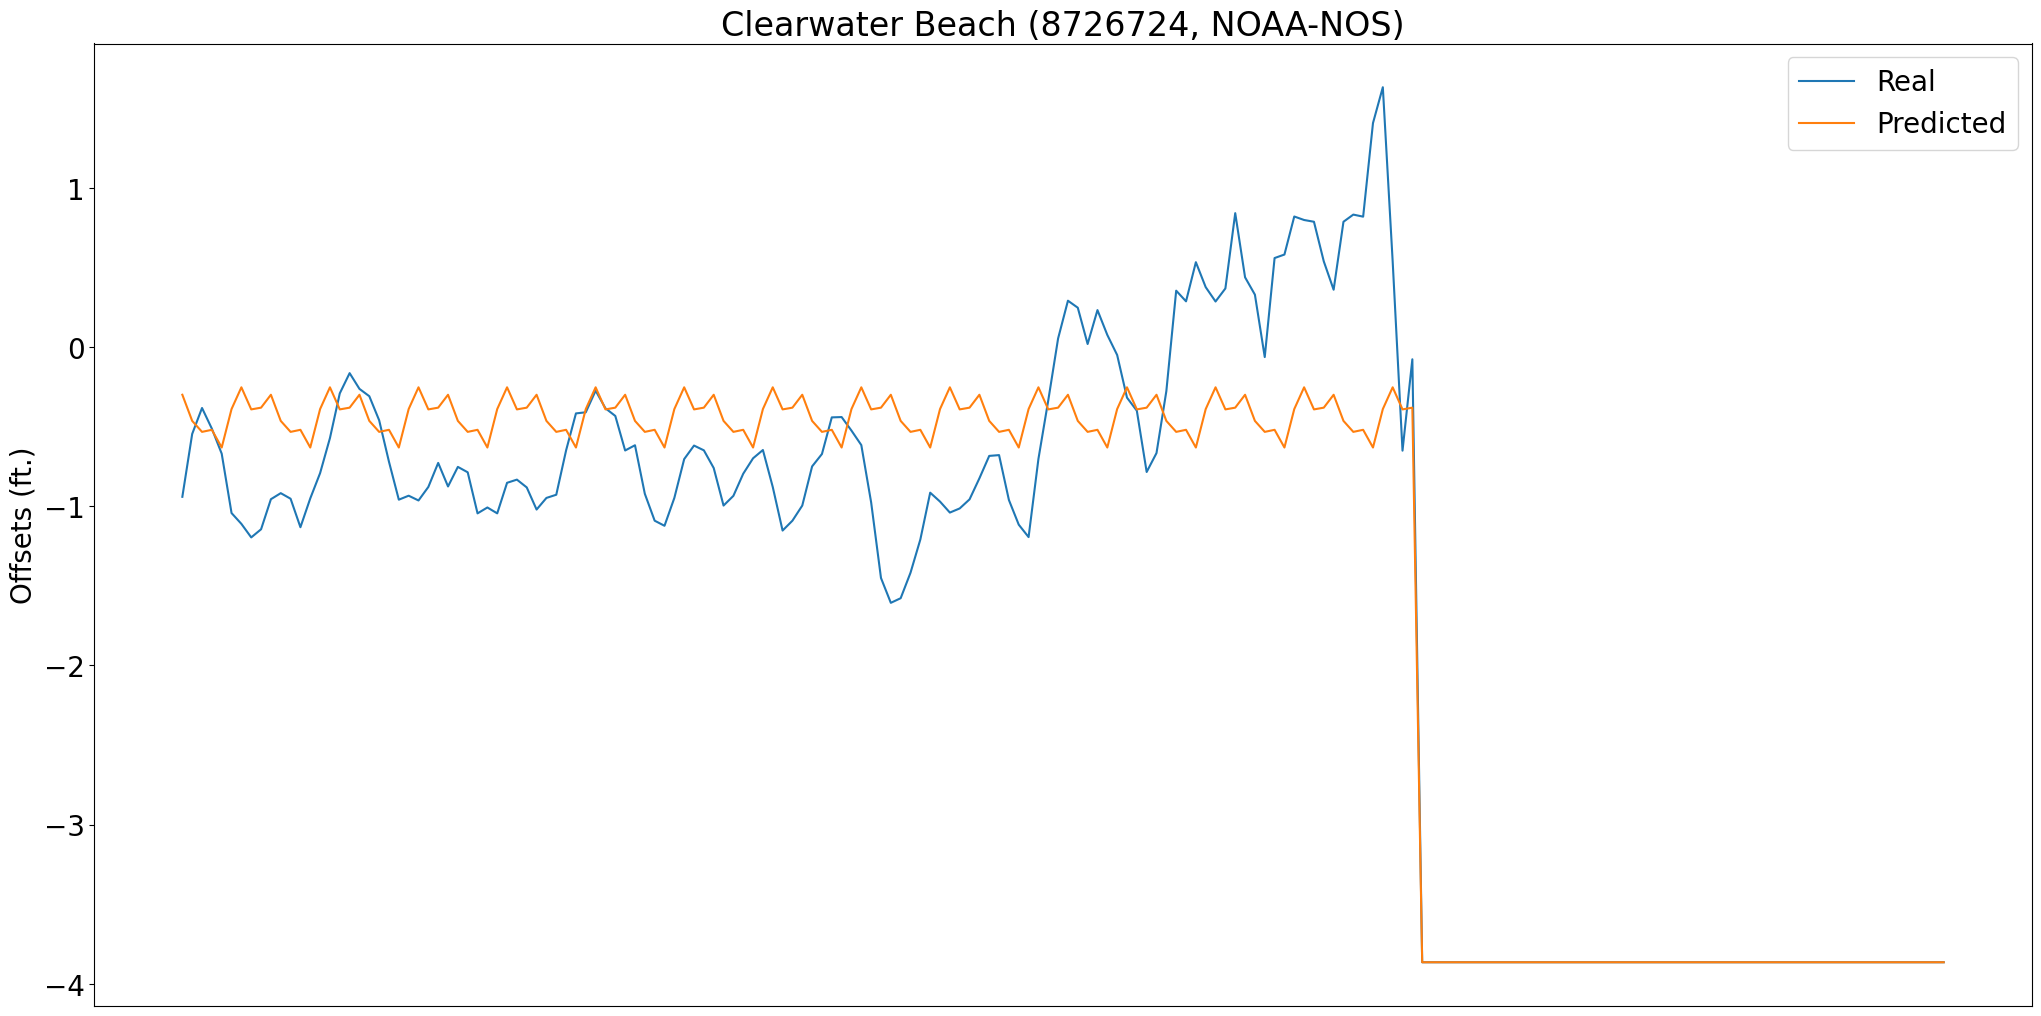

R² = 0.89
RMSE = 0.55
MAE = 0.38


In [53]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# id='219897993'
# id='8670870'
# id='8661070'
id='8726724'

Ids=station_df_test.columns.values
node = np.where(Ids == id)[0][0]
station_name = data_df[data_df['station_id']==id]['station_name'].unique()[0]
agency = data_df[data_df['station_id']==id]['agency'].unique()[0].replace('_','-')


# just get the first prediction out for the nth node
y_truth_station = y_truth[:, :, node, :].flatten()
# Flatten to get the predictions for entire test dataset
# y_truth_station = torch.flatten(y_truth_station)

# just get the first prediction out for the nth node
y_pred_station = y_pred[:, :, node, :].flatten()
# Flatten to get the predictions for entire test dataset
# y_pred_station = torch.flatten(y_pred_station)

plt.plot(y_truth_station, label = 'Real')
plt.plot(y_pred_station, label = 'Predicted')
plt.legend()
plt.ylabel('Offsets (ft.)')
plt.xticks([])
title_str = station_name + f' ({str(id)}, {agency})'
plt.title(title_str)

plt.show()

print("R\u00b2 = {:.2f}".format(r2_score(y_truth_station, y_pred_station)))
print("RMSE = {:.2f}".format(np.sqrt(mean_squared_error(y_truth_station, y_pred_station))))
print("MAE = {:.2f}".format(mean_absolute_error(y_truth_station, y_pred_station)))


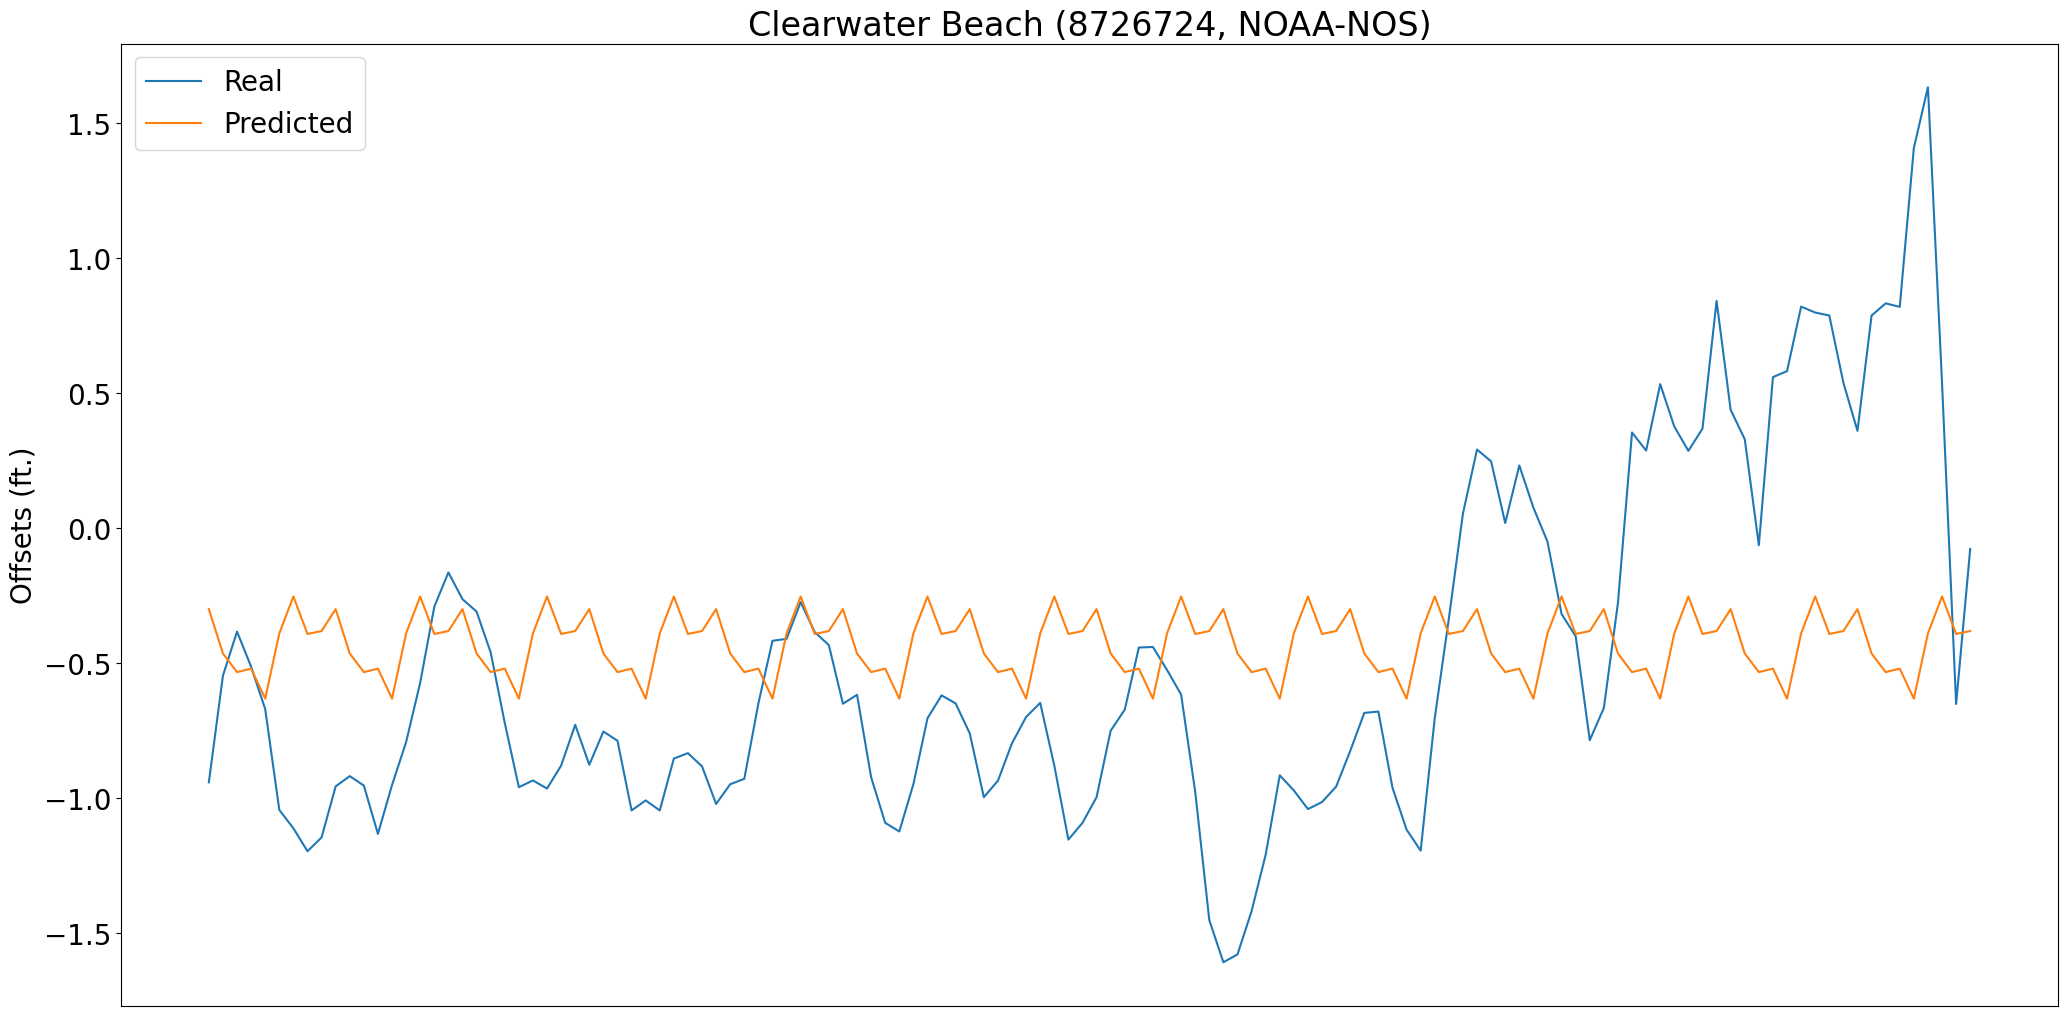

R² = -0.05
RMSE = 0.66
MAE = 0.54


In [54]:
plt.plot(y_truth_station[:126], label = 'Real')
plt.plot(y_pred_station[:126], label = 'Predicted')
plt.legend()
plt.ylabel('Offsets (ft.)')
plt.xticks([])
title_str = station_name + f' ({str(id)}, {agency})'
plt.title(title_str)

plt.show()

print("R\u00b2 = {:.2f}".format(r2_score(y_truth_station[:126], y_pred_station[:126])))
print("RMSE = {:.2f}".format(np.sqrt(mean_squared_error(y_truth_station[:126], y_pred_station[:126]))))
print("MAE = {:.2f}".format(mean_absolute_error(y_truth_station[:126], y_pred_station[:126])))

<function matplotlib.pyplot.legend(*args, **kwargs)>

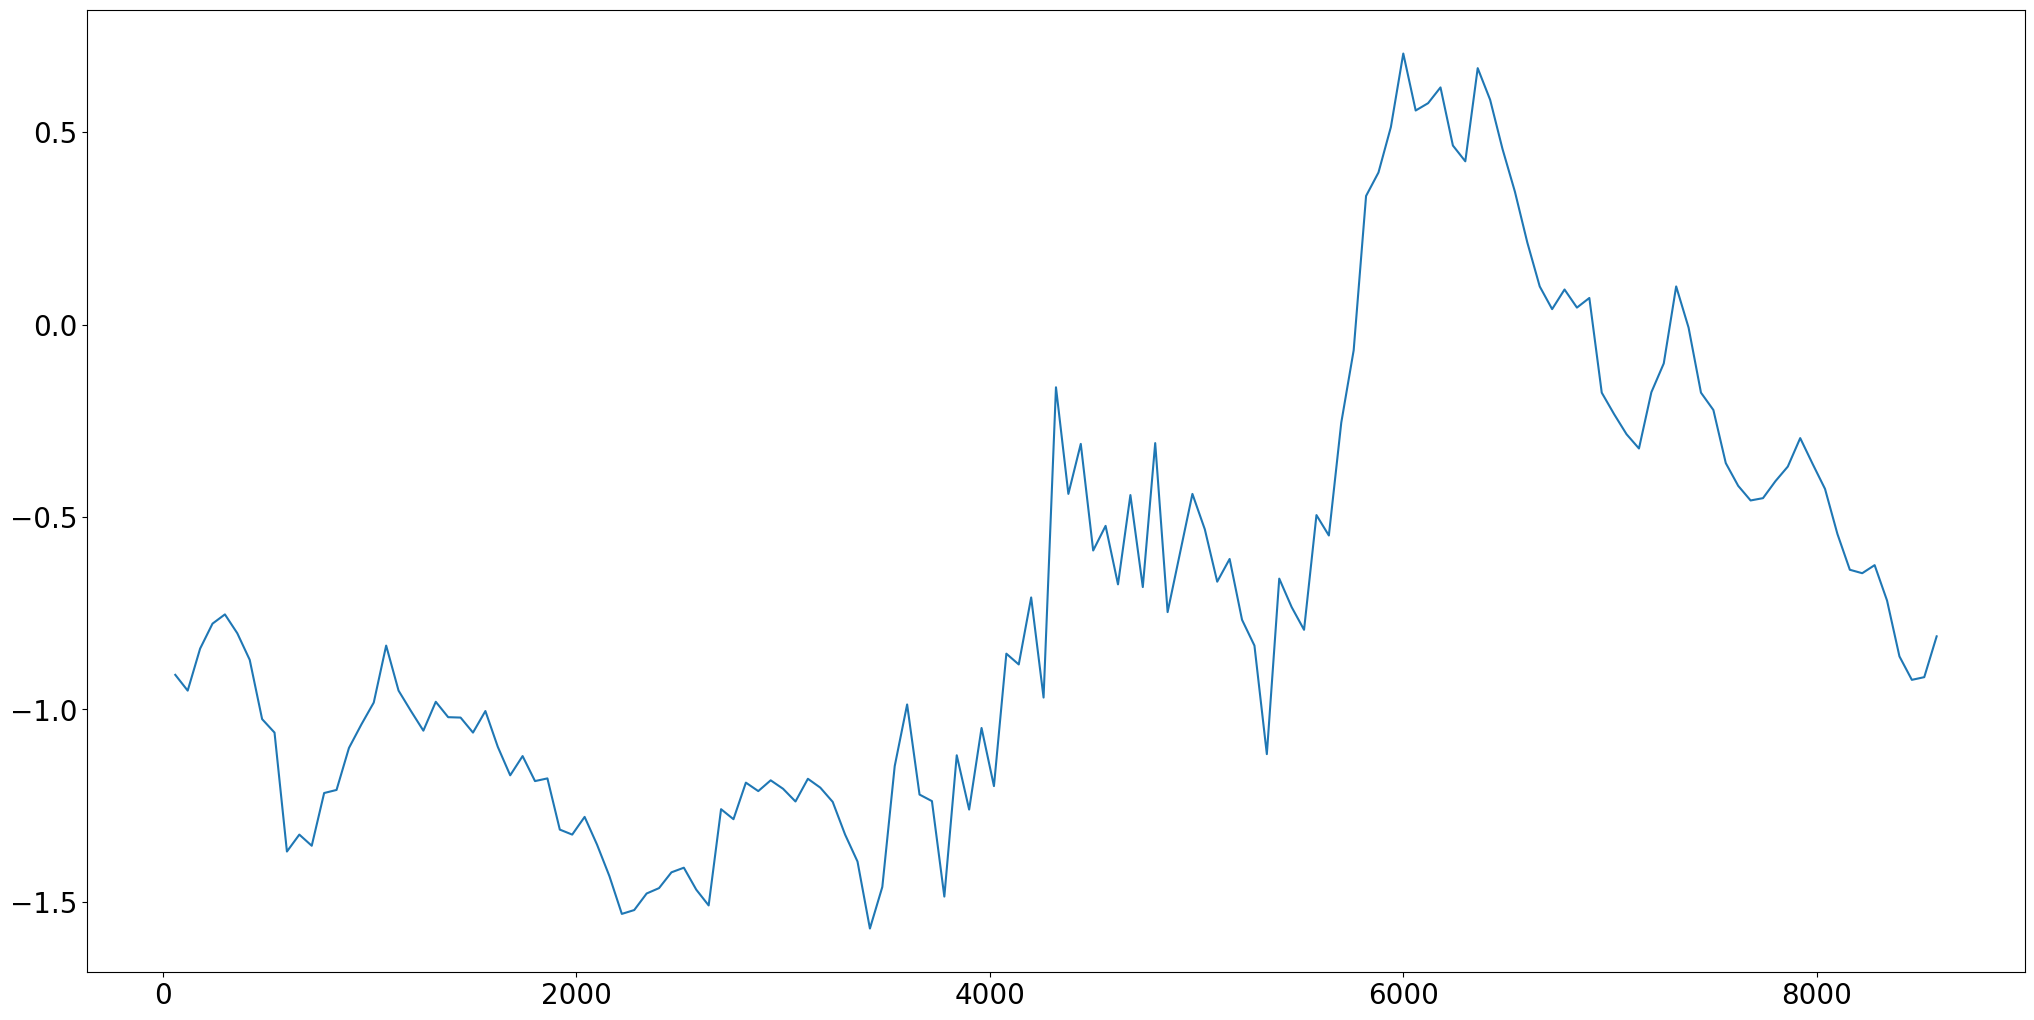

In [55]:
data_df_test = data_df[data_df['storm']=='IAN'].dropna()
df_plot = data_df_test[(data_df_test['station_id']==id)].dropna()[['time_UTC_dt', 'observed_data', 'forecast_data', 'offset']]
plt.plot(df_plot['time_UTC_dt'], df_plot['offset'], label='Forecast')
plt.legend


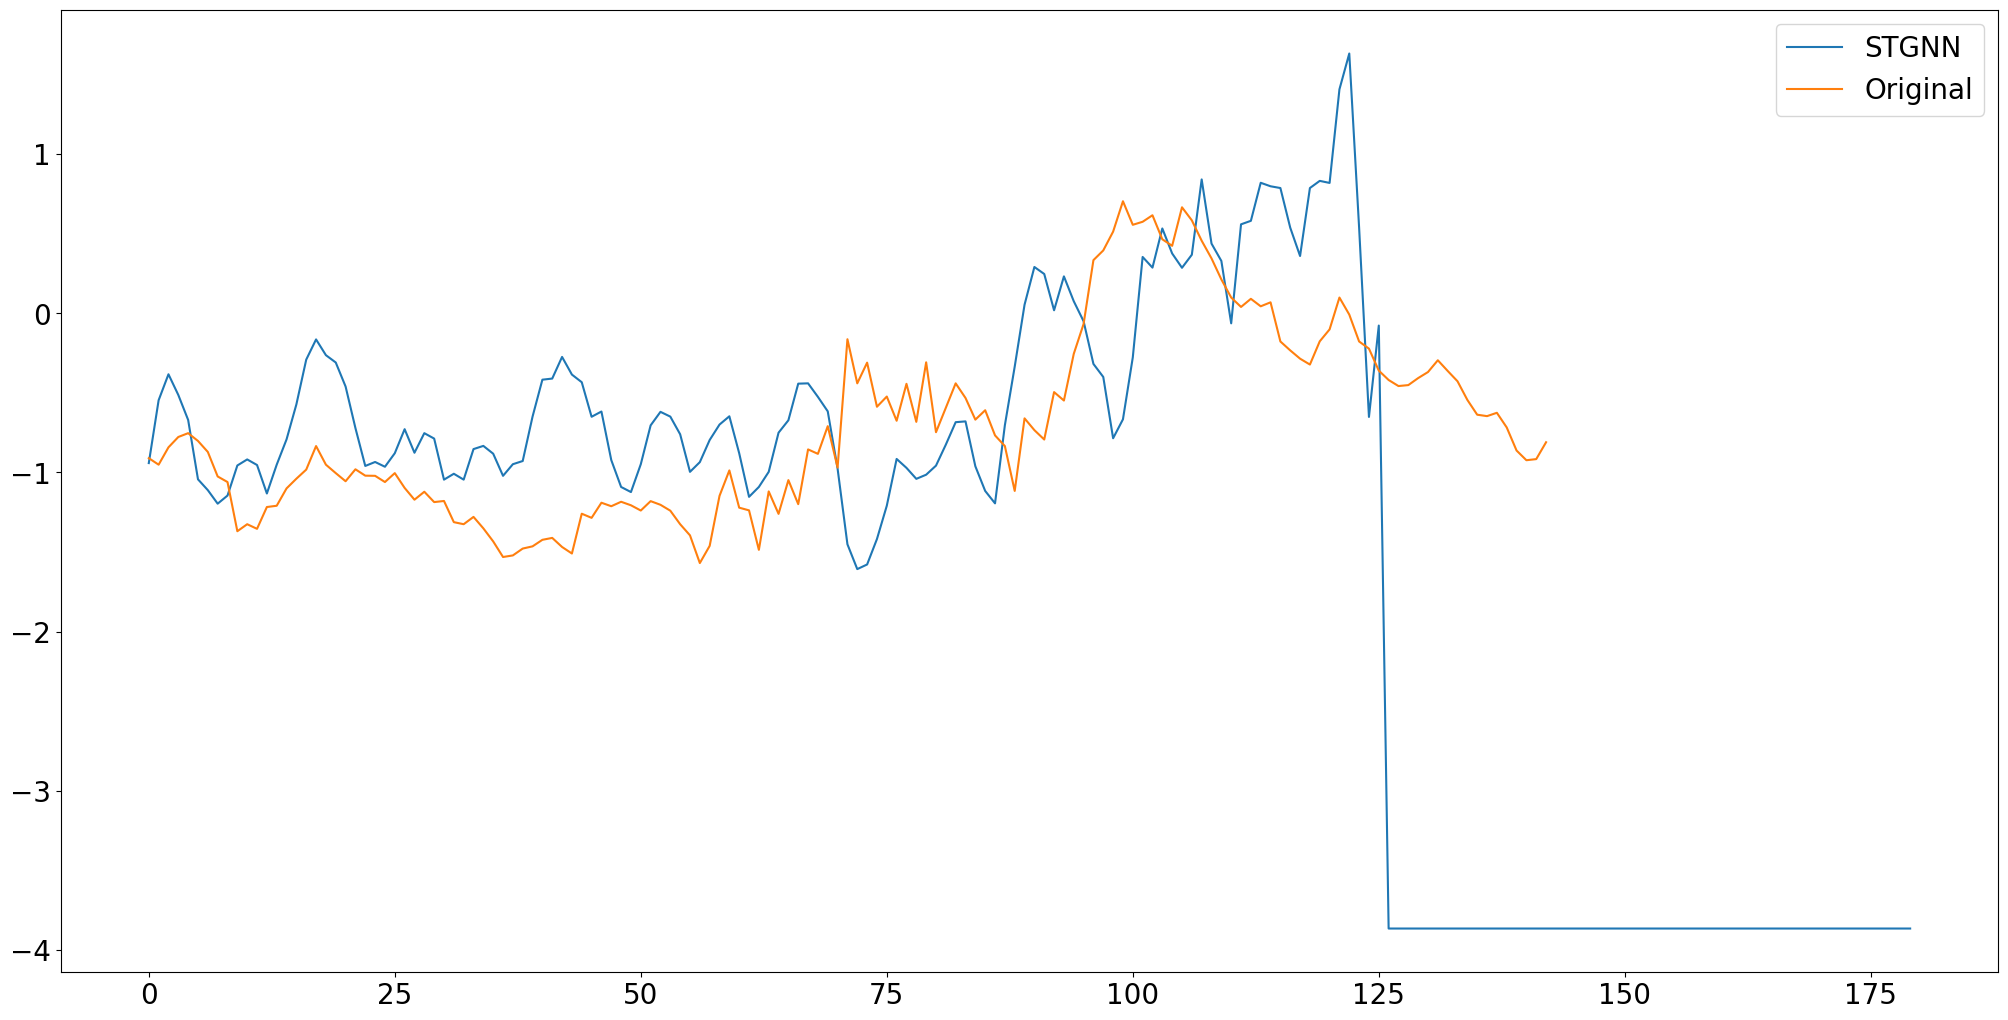

In [59]:
plt.plot(y_truth_station, label = 'STGNN')
plt.plot(df_plot['offset'].values, label='Original')
plt.legend()



In [71]:
len(df_plot['offset'].values)

143

143
180


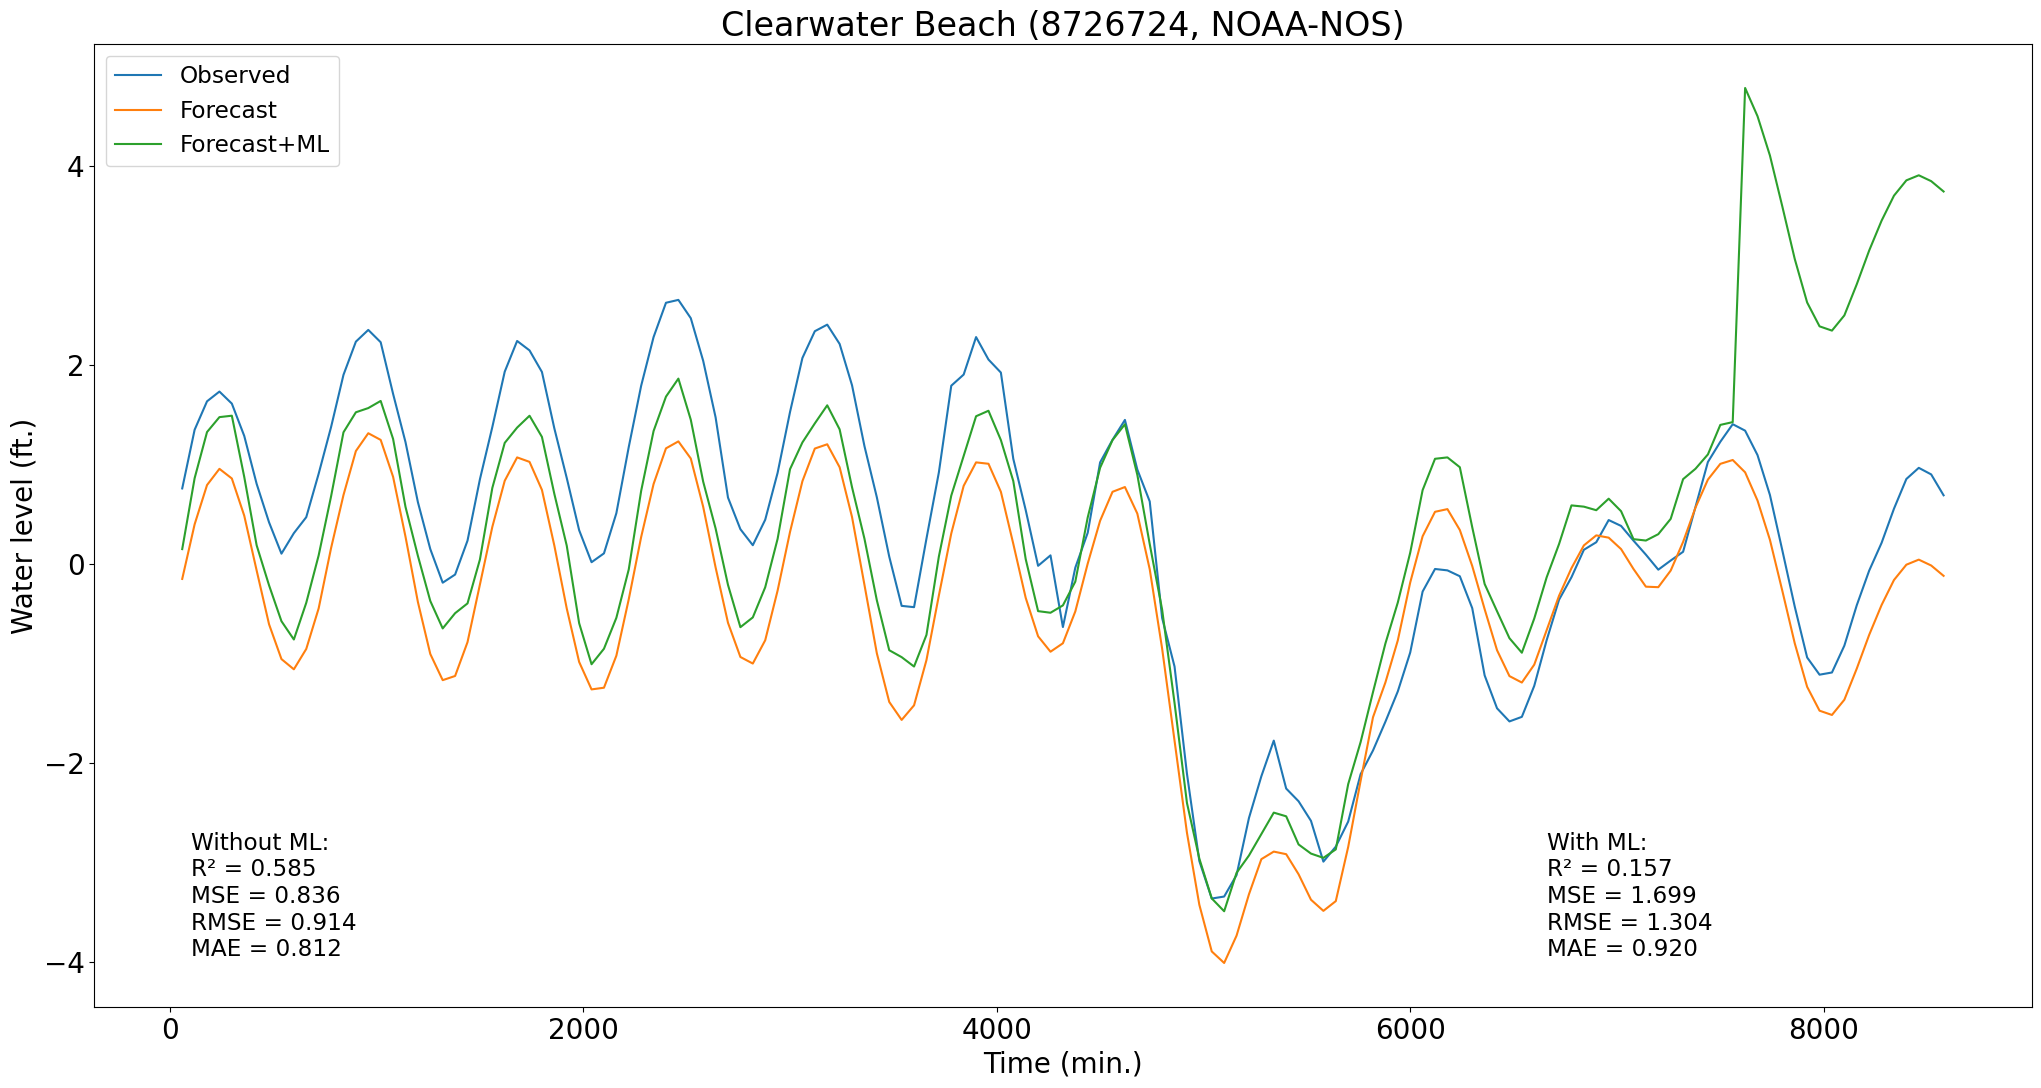

In [60]:
data_df_test = data_df[data_df['storm']=='IAN'].dropna()
df_plot = data_df_test[(data_df_test['station_id']==id)].dropna()[['time_UTC_dt', 'observed_data', 'forecast_data', 'offset']]

y_pred_station = y_pred[:, :, node, :].flatten()

# y_pred_station = np.append(np.ones(config['N_HIST'])*np.nan, y_pred_station)
print(len(df_plot['forecast_data'].values))
print(len(y_pred_station))
# padding_nan = np.ones(len(df_plot['forecast_data'].values)-len(y_pred_station))*np.nan
# y_pred_station = np.append(padding_nan, y_pred_station)

df_plot['corr_forecast_data'] = df_plot['forecast_data'] - y_pred_station[:len(df_plot['forecast_data'])]

df_plot=df_plot.dropna().sort_values(by=['time_UTC_dt'])


# stats for observed - forecast
r_sq_obs_for = r2_score(df_plot['observed_data'], df_plot['forecast_data'])
mse_obs_for = mean_squared_error(df_plot['observed_data'], df_plot['forecast_data'])
rmse_obs_for = np.sqrt(mean_squared_error(df_plot['observed_data'], df_plot['forecast_data']))
mae_obs_for = mean_absolute_error(df_plot['observed_data'], df_plot['forecast_data'])
    

# stats for observed - corr. forecast
r_sq_obs_corr = r2_score(df_plot['observed_data'], df_plot['corr_forecast_data'])
mse_obs_corr = mean_squared_error(df_plot['observed_data'], df_plot['corr_forecast_data'])
rmse_obs_corr = np.sqrt(mean_squared_error(df_plot['observed_data'], df_plot['corr_forecast_data']))
mae_obs_corr = mean_absolute_error(df_plot['observed_data'], df_plot['corr_forecast_data'])

evaluation_stats = [r_sq_obs_for, mse_obs_for, rmse_obs_for, mae_obs_for, r_sq_obs_corr, mse_obs_corr, rmse_obs_corr, mae_obs_corr]

plt.plot(df_plot['time_UTC_dt'], df_plot['observed_data'], label='Observed')
plt.plot(df_plot['time_UTC_dt'], df_plot['forecast_data'], label='Forecast')
plt.plot(df_plot['time_UTC_dt'], df_plot['corr_forecast_data'], label='Forecast+ML')
plt.xlabel('Time (min.)')
plt.ylabel('Water level (ft.)')

# stats for observed - forecast
r_sq_str = "R\u00b2 = {:.3f}\n".format(evaluation_stats[0])
mse_str = "MSE = {:.3f}\n".format(evaluation_stats[1])
rmse_str = "RMSE = {:.3f}\n".format(evaluation_stats[2])
mae_str = "MAE = {:.3f}\n".format(evaluation_stats[3])
stat_str = 'Without ML:\n' + r_sq_str + mse_str + rmse_str + mae_str
annotation = plt.annotate(stat_str, xy=(0.05, 0.025), xycoords='axes fraction', fontsize='small')
annotation.set_bbox(dict(facecolor='white', alpha=0.5, linewidth=0))

# stats for observed - corr. forecast
r_sq_str = "R\u00b2 = {:.3f}\n".format(evaluation_stats[4])
mse_str = "MSE = {:.3f}\n".format(evaluation_stats[5])
rmse_str = "RMSE = {:.3f}\n".format(evaluation_stats[6])
mae_str = "MAE = {:.3f}\n".format(evaluation_stats[7])
stat_str = 'With ML:\n' + r_sq_str + mse_str + rmse_str + mae_str
annotation = plt.annotate(stat_str, xy=(0.75, 0.025), xycoords='axes fraction', fontsize='small')
annotation.set_bbox(dict(facecolor='white', alpha=0.5, linewidth=0))
plt.legend(loc='upper left', fontsize='small')
title_str = station_name + f' ({str(id)}, {agency})'
plt.title(title_str)
# plt.savefig(filename_plot)
plt.show()

